# Decoded Plots

In [120]:
import sys
import importlib
import pandas as pd
from pathlib import Path
from matplotlib.figure import Figure
import matplotlib as plt

repo_src = None
repo_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "plots" / "plot_helpers.py").exists():
        repo_src = base / "src" / "plots"
        repo_root = base
        break
    if (base / "plots" / "plot_helpers.py").exists():
        repo_src = base / "plots"
        repo_root = base.parent
        break
    if (base / "plot_helpers.py").exists():
        repo_src = base
        repo_root = base.parent.parent
        break

if repo_src is None or repo_root is None:
    raise FileNotFoundError("Could not locate plot_helpers.py")

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import plot_helpers

importlib.reload(plot_helpers)

plt.rcParams.update(
    {
        "axes.titlesize": 14,  # Title
        "axes.labelsize": 14,  # X and Y labels
        "xtick.labelsize": 14,  # X tick labels
        "ytick.labelsize": 14,  # Y tick labels
        "legend.fontsize": 14,  # Legend
    }
)

paths = {
    "bpsk": repo_root / "output" / "260618_decoded_ultimate_bpsk.csv",
    "dbpsk": repo_root / "output" / "260618_decoded_ultimate_dbpsk.csv",
}

algorithm = "dbpsk"
source = pd.read_csv(
    paths[algorithm],
)

cycles_per_symbol = 2
cycles_per_symbol = 5
cycles_per_symbol = 7
source = source[source["cycles_per_symbol"] == cycles_per_symbol]
# source = source[source["frequency"] < 250]

df_first = source[source["type"] == "compressed"]
df_second = source[source["type"] == "uncompressed"]

LABEL_FIRST: str = f"{algorithm} with WhatsApp"
LABEL_SECOND: str = f"{algorithm} best scenario"

SAVE: bool = True


def savefigs(figures: list[Figure], label: str) -> None:
    if not SAVE:
        return
    for i, fig in enumerate(figures):
        fig.savefig(
            f"{repo_root}/output/plots/{algorithm}/{label}_period{cycles_per_symbol}_{i}.pdf",
            bbox_inches="tight",
        )

# Comparison between DBPSK and BPSK
From this comparison we can analyze what actually gets recognized in the file: is the preamble recognized? Is the decoded payload long enough?
These are the possible errors:
* `not-valid-preamble`: the preamble has not been recognized
* `check-error`: safety guards on the waveform properties
* `no-length-in-header`: the header is shorter than 16 bits, which are used to represent the number of bytes of the payload
* `paylod-too-short`: the payload is shorter than the number of bytes that are in the header

If there is no error, the status is `valid-preamble`.

In [121]:
from plot_helpers import print_decode_status, print_error_comparison

print(f"{LABEL_FIRST}:")
print_decode_status(df_first)
print()
print(f"{LABEL_SECOND}:")
print_decode_status(df_second)
print()
print_error_comparison(
    df_first,
    df_second,
    LABEL_FIRST,
    LABEL_SECOND,
)

dbpsk with WhatsApp:
valid preambles: 68
not valid: 178
errors: 4
types of error: ['paylod-too-short', 'unsupported-ecc-scheme']

dbpsk best scenario:
valid preambles: 250
not valid: 0
errors: 0
types of error: []

Mean error dbpsk with WhatsApp: 0.7312
Mean error dbpsk best scenario: 0.0009
Variance error dbpsk with WhatsApp: 0.1881
Variance error dbpsk best scenario: 0.0001

dbpsk with WhatsApp is better than dbpsk best scenario: 0, 0.0%
dbpsk with WhatsApp is equal to dbpsk best scenario: 0, 0.0%
dbpsk with WhatsApp is worse than dbpsk best scenario: 0, 0.0%
Mean improvement: nan
Improvement variance: nan
Mean worsening: nan
Worsening variance: nan


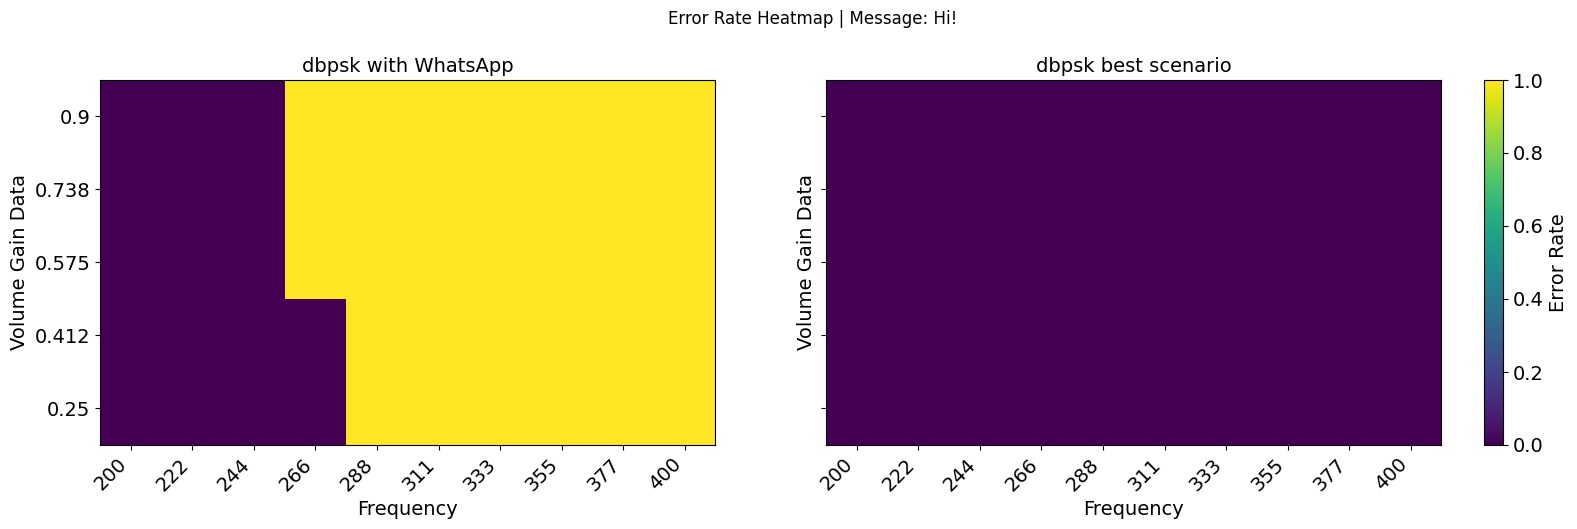

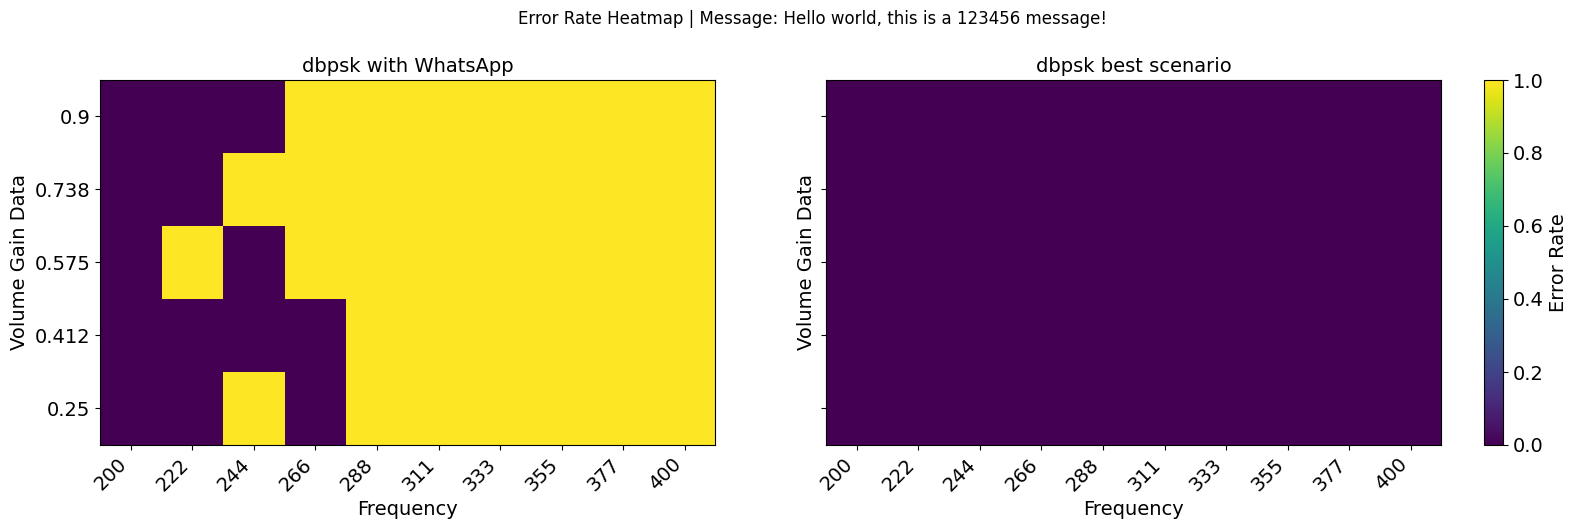

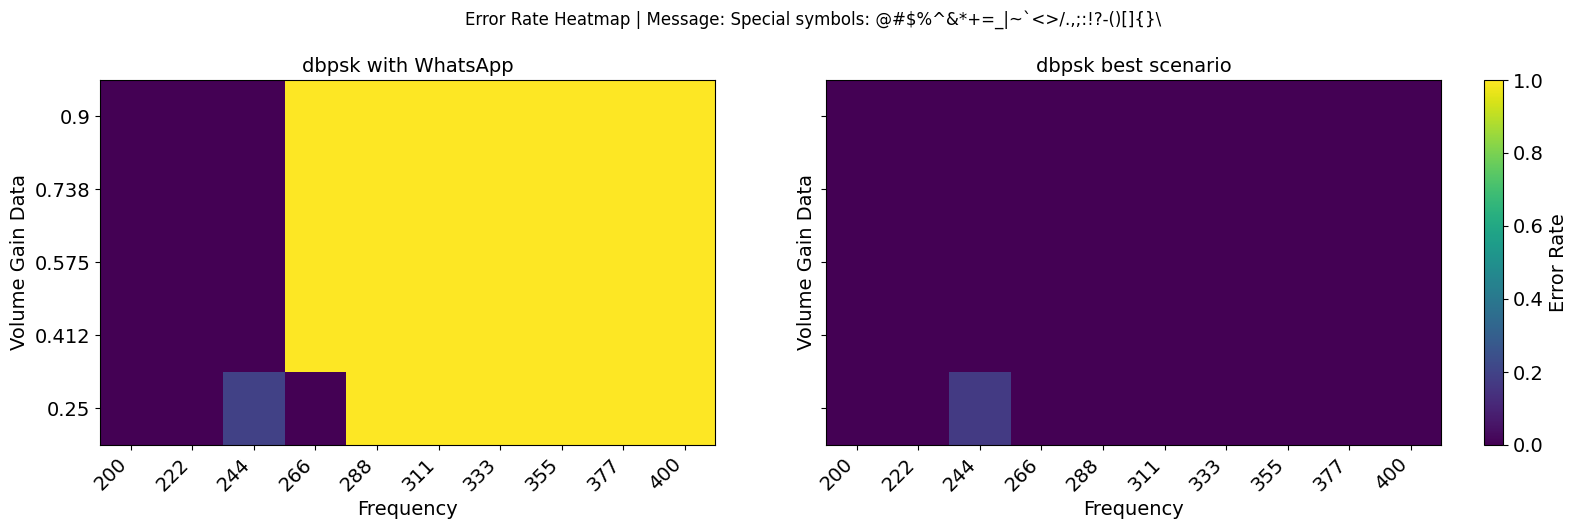

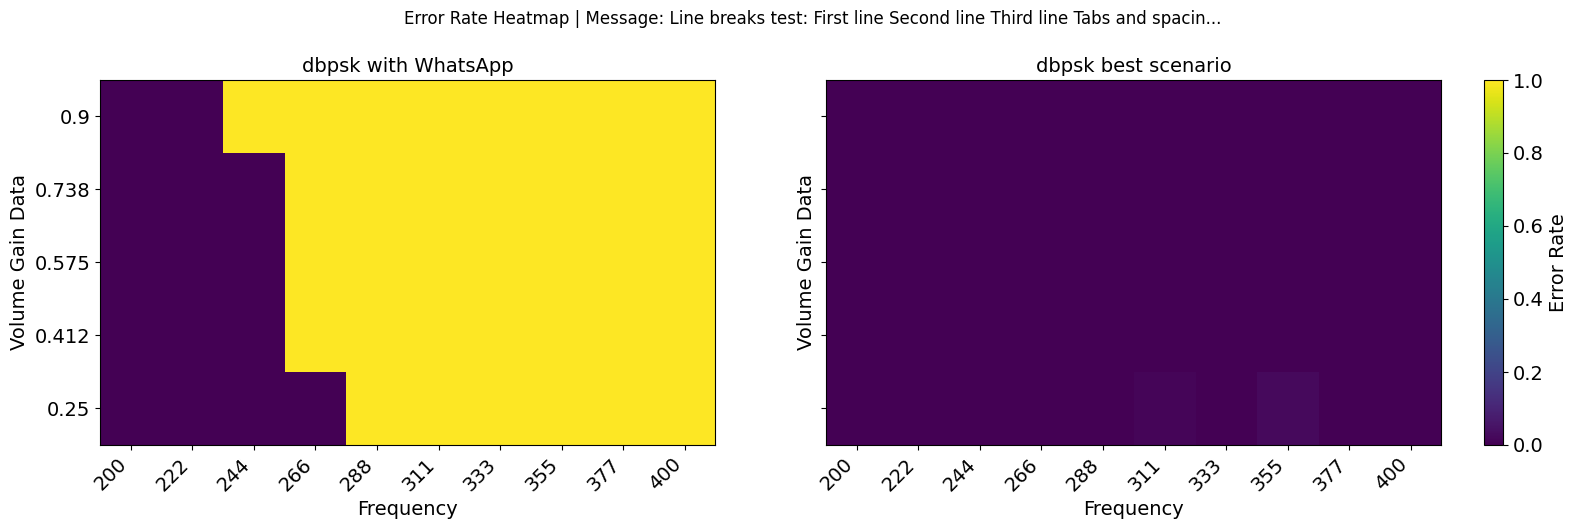

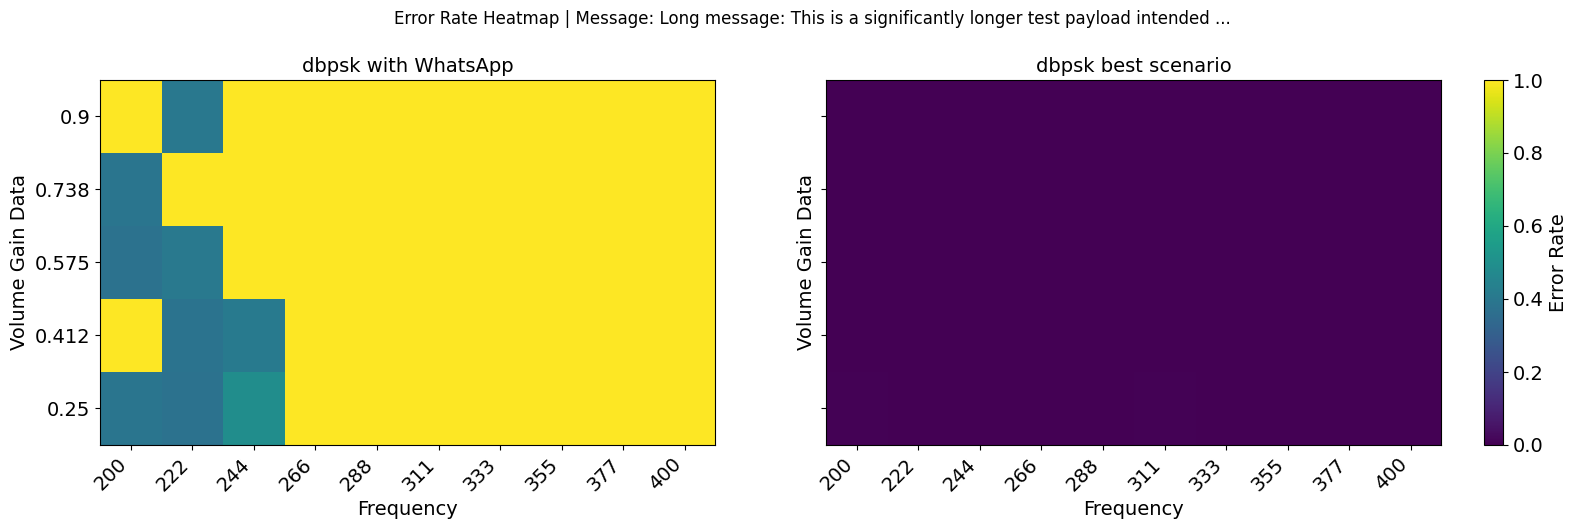

In [122]:
from plot_helpers import plot_error_rate_heatmaps_by_message_comparison

figures = plot_error_rate_heatmaps_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)
savefigs(figures, "heatmap")

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

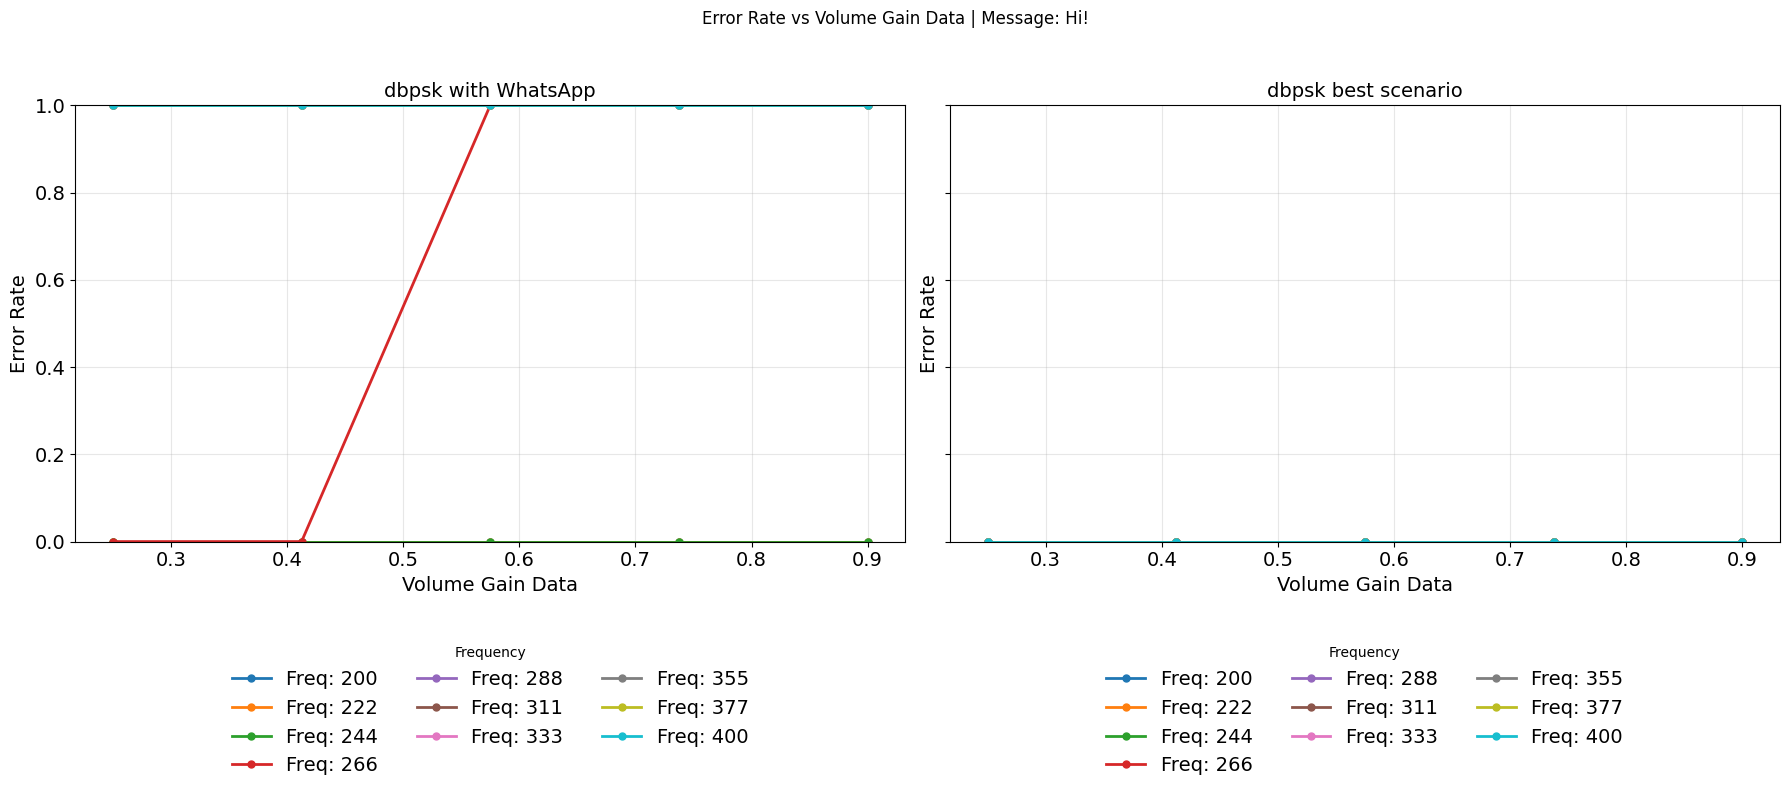

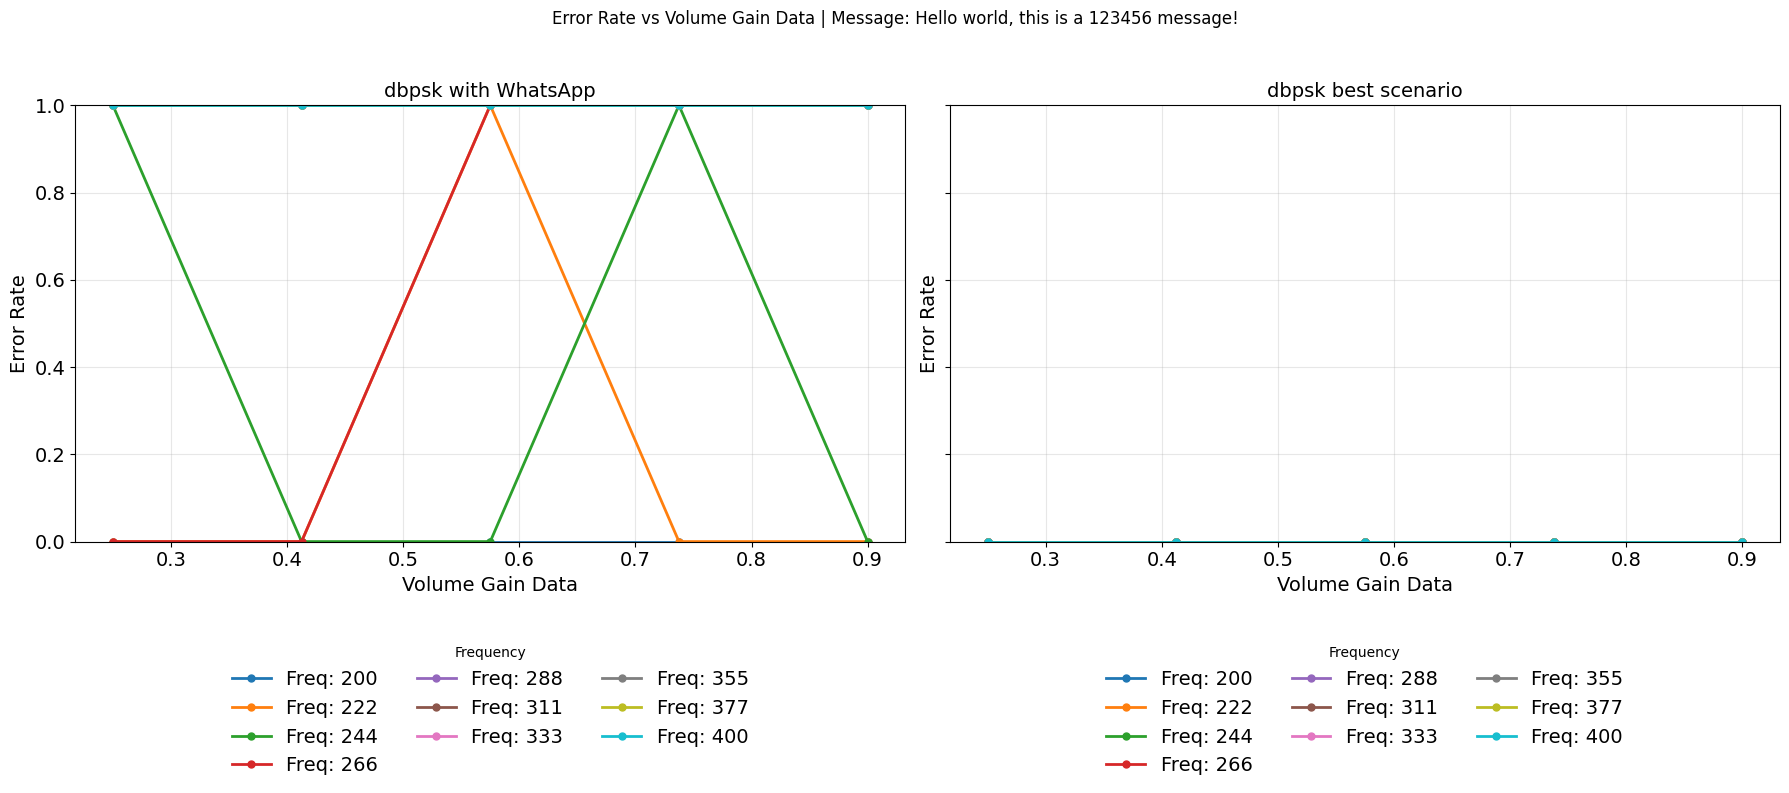

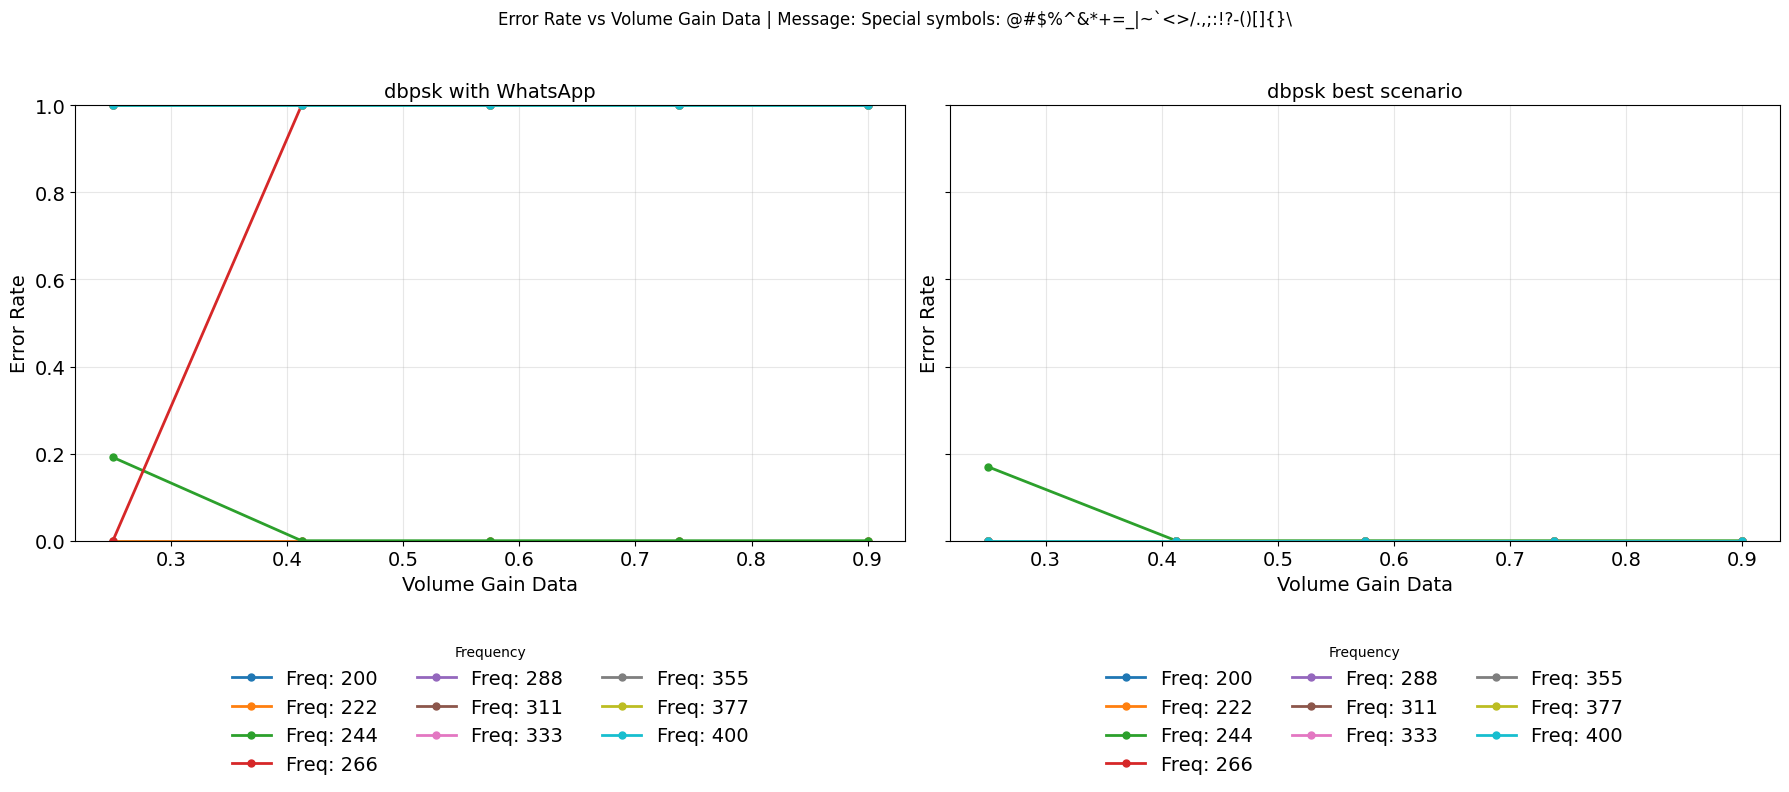

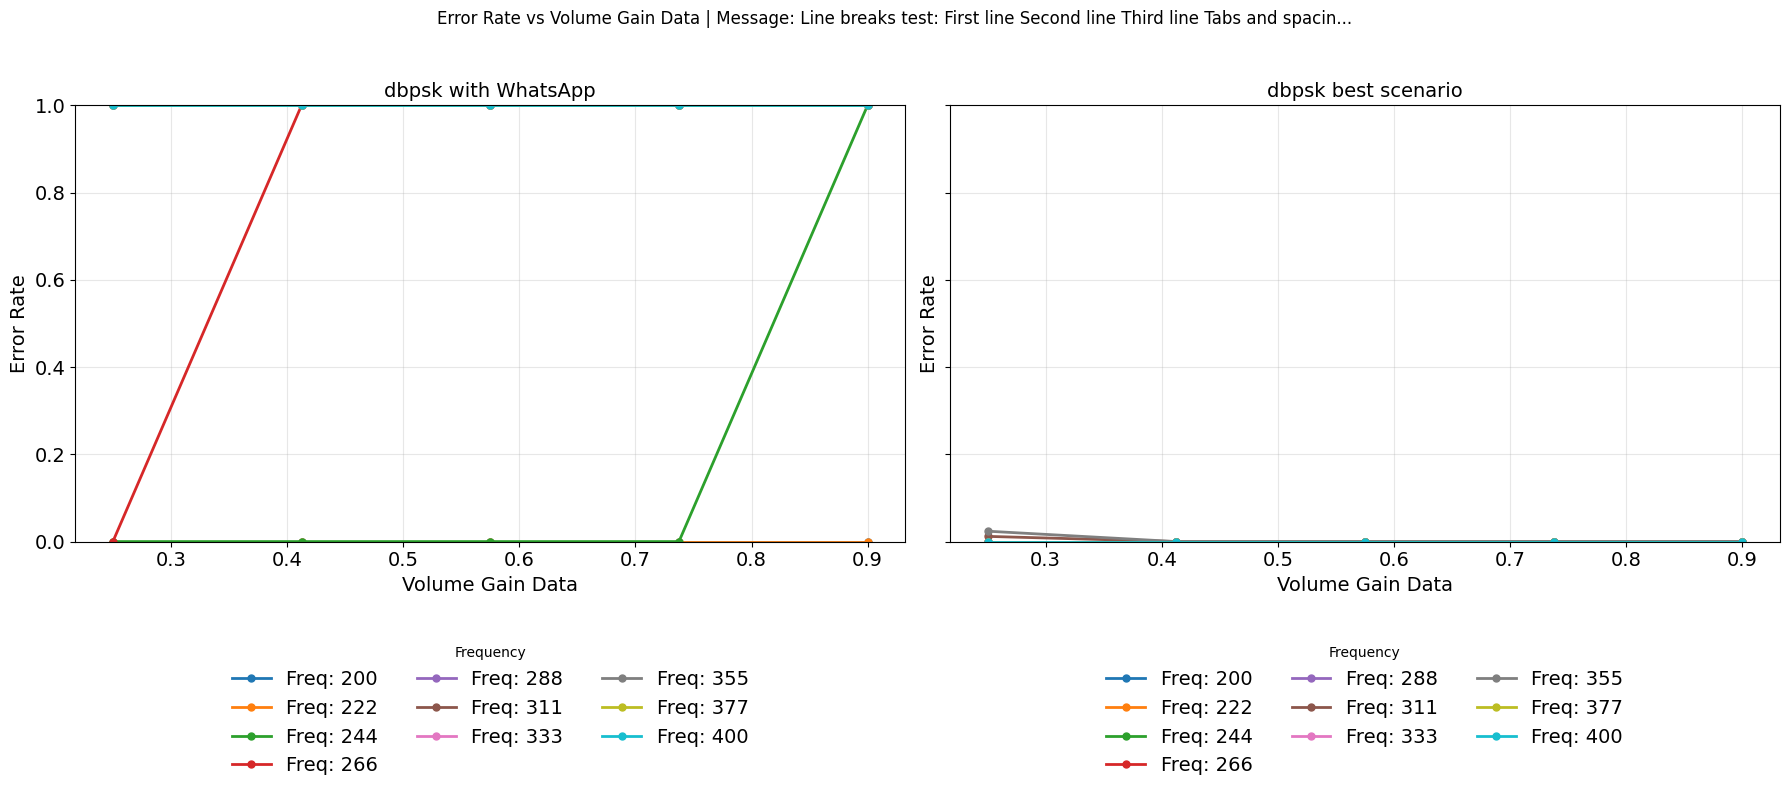

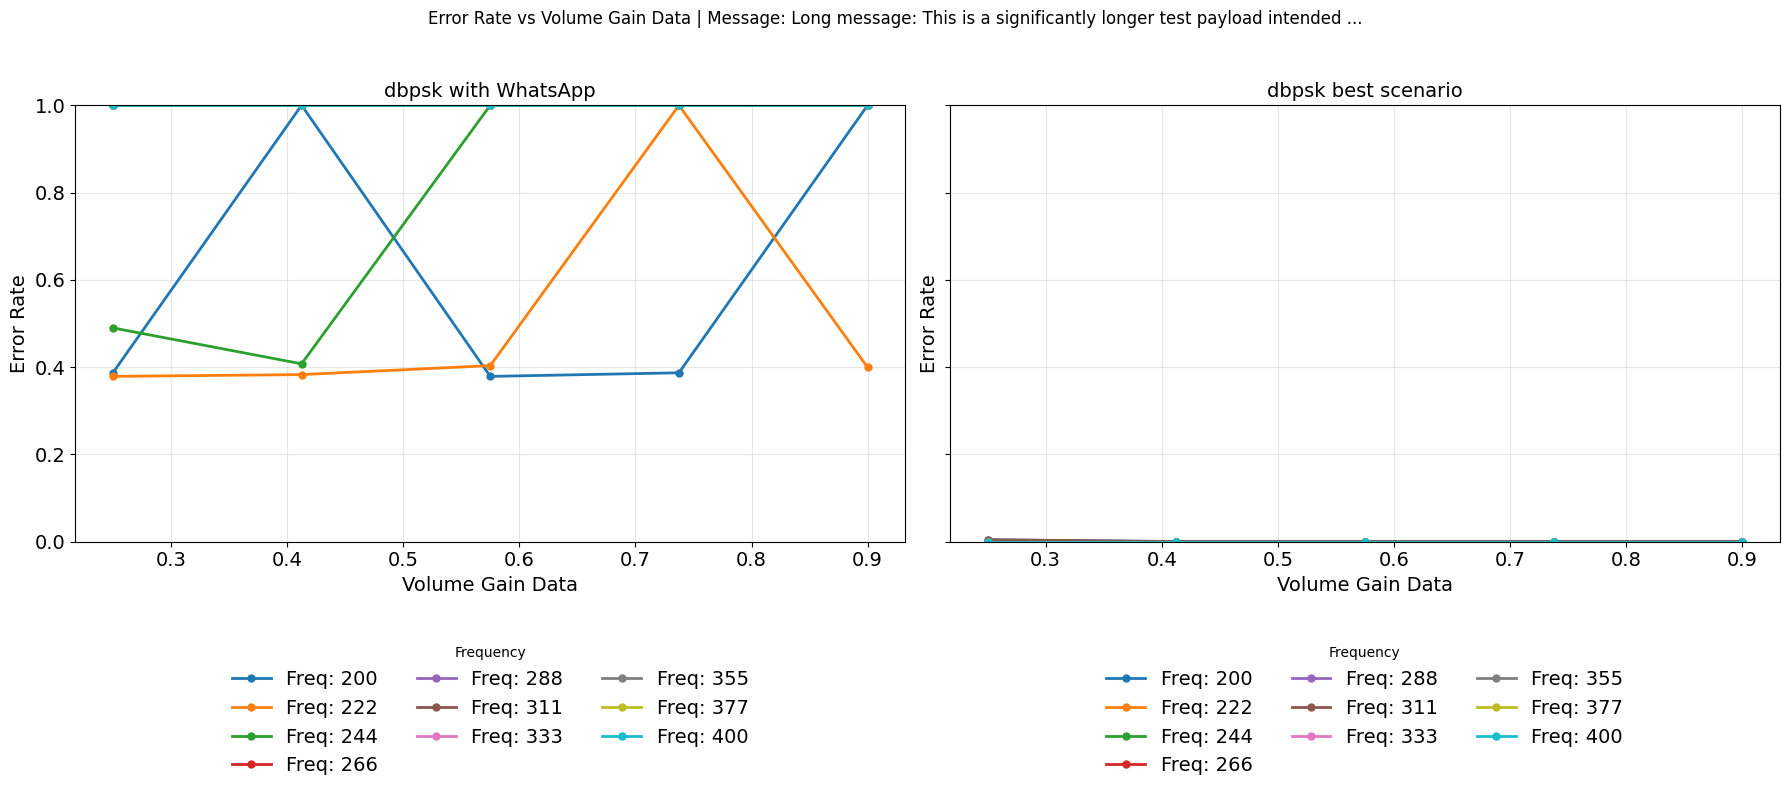

In [123]:
from plot_helpers import plot_error_rate_vs_frequency_by_message_comparison

figures = plot_error_rate_vs_frequency_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)
savefigs(figures, "lineplot")

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 5 comparison plots (one per volume_gain_data).


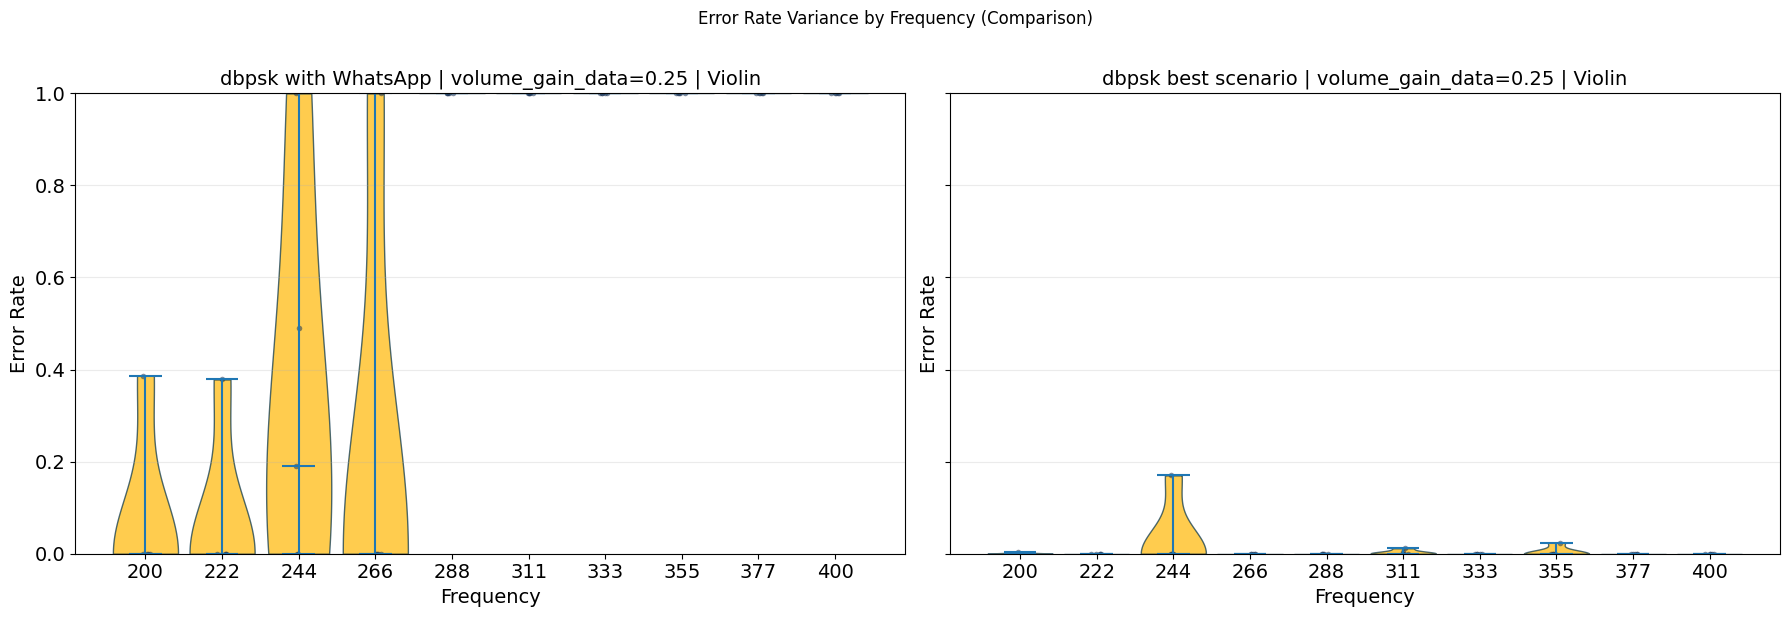

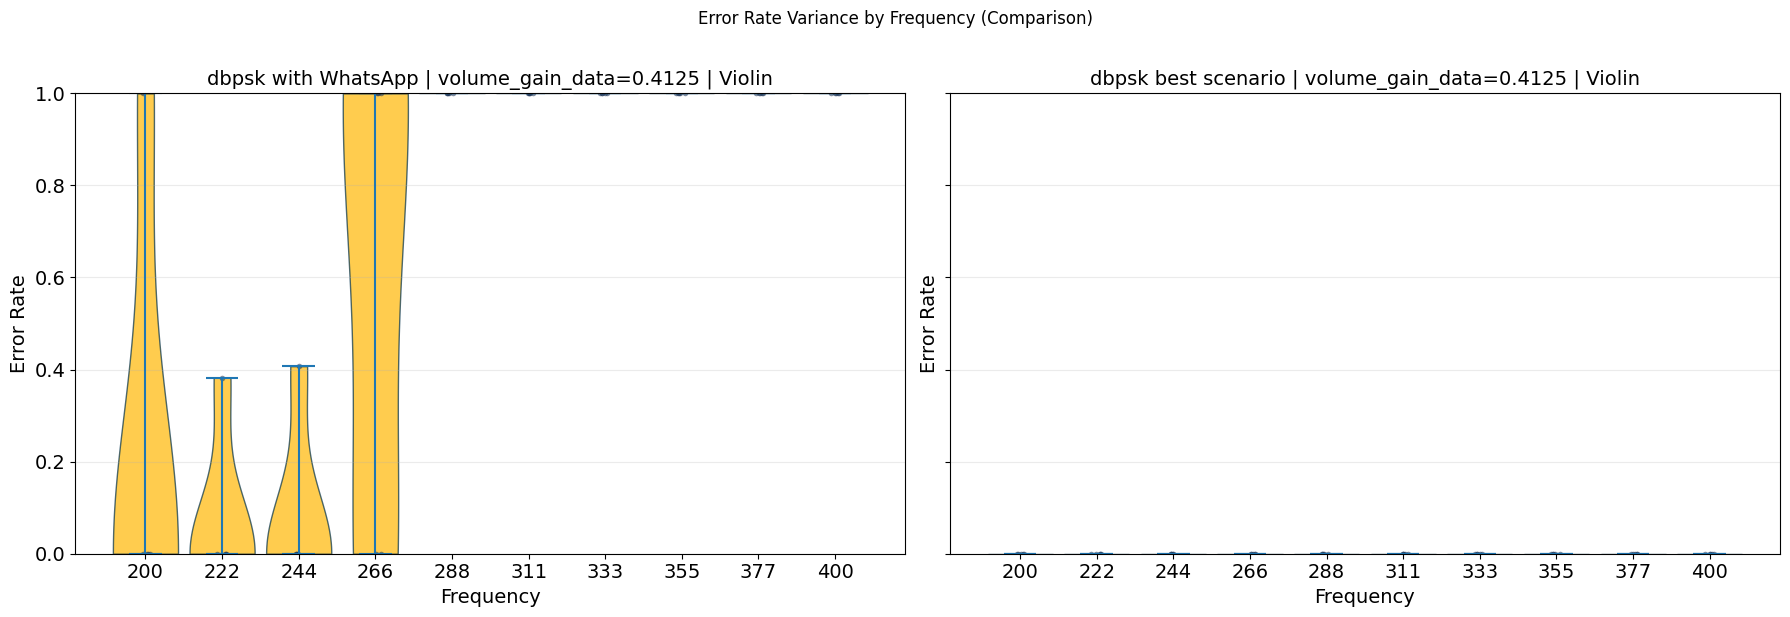

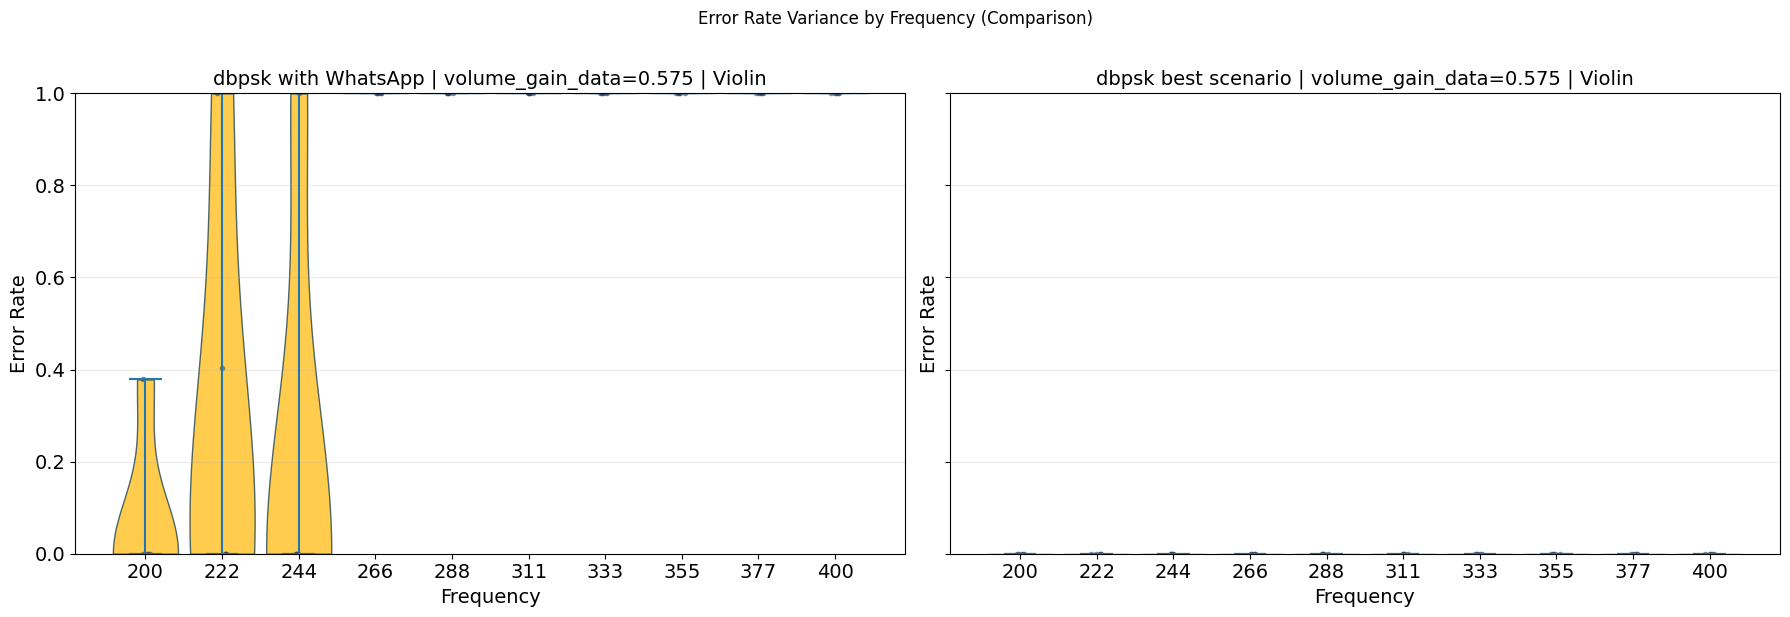

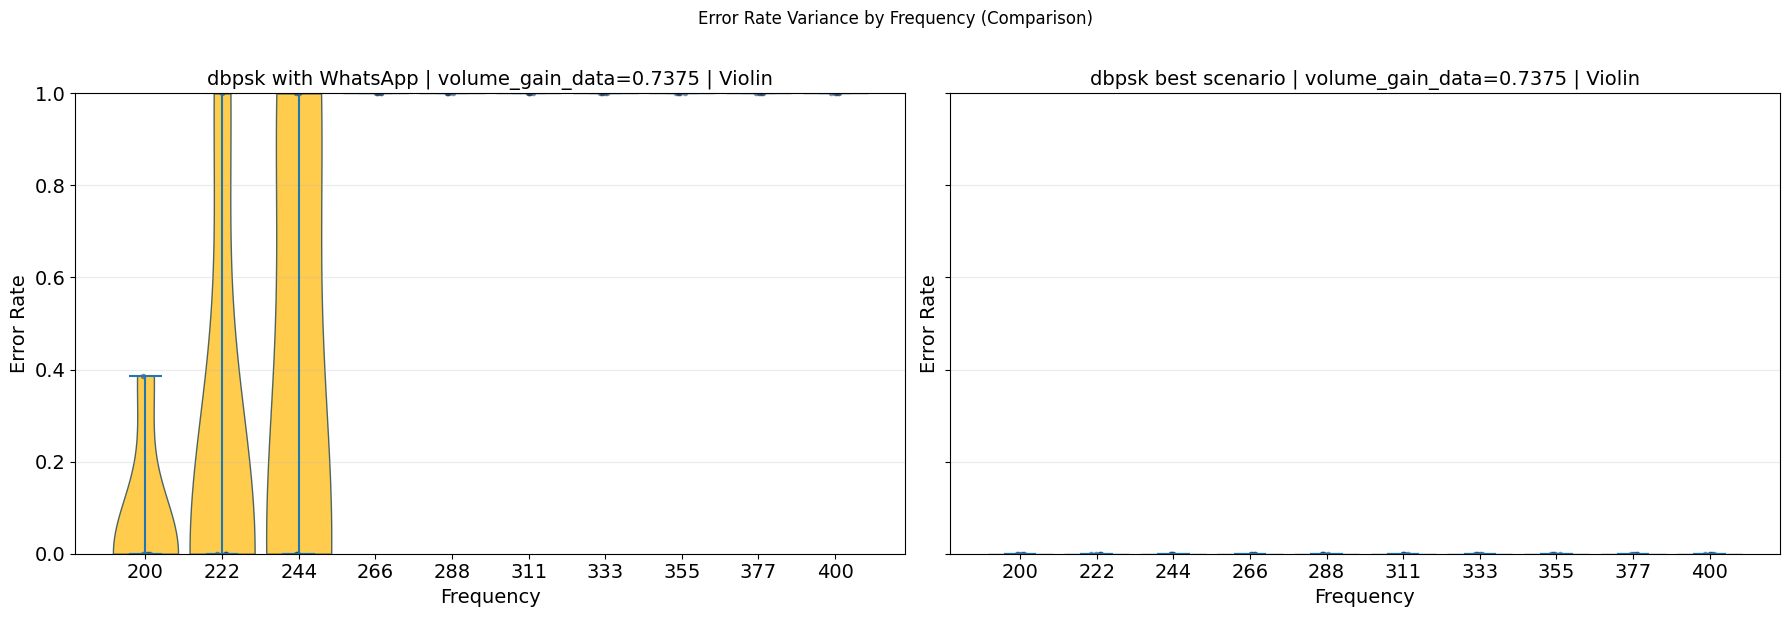

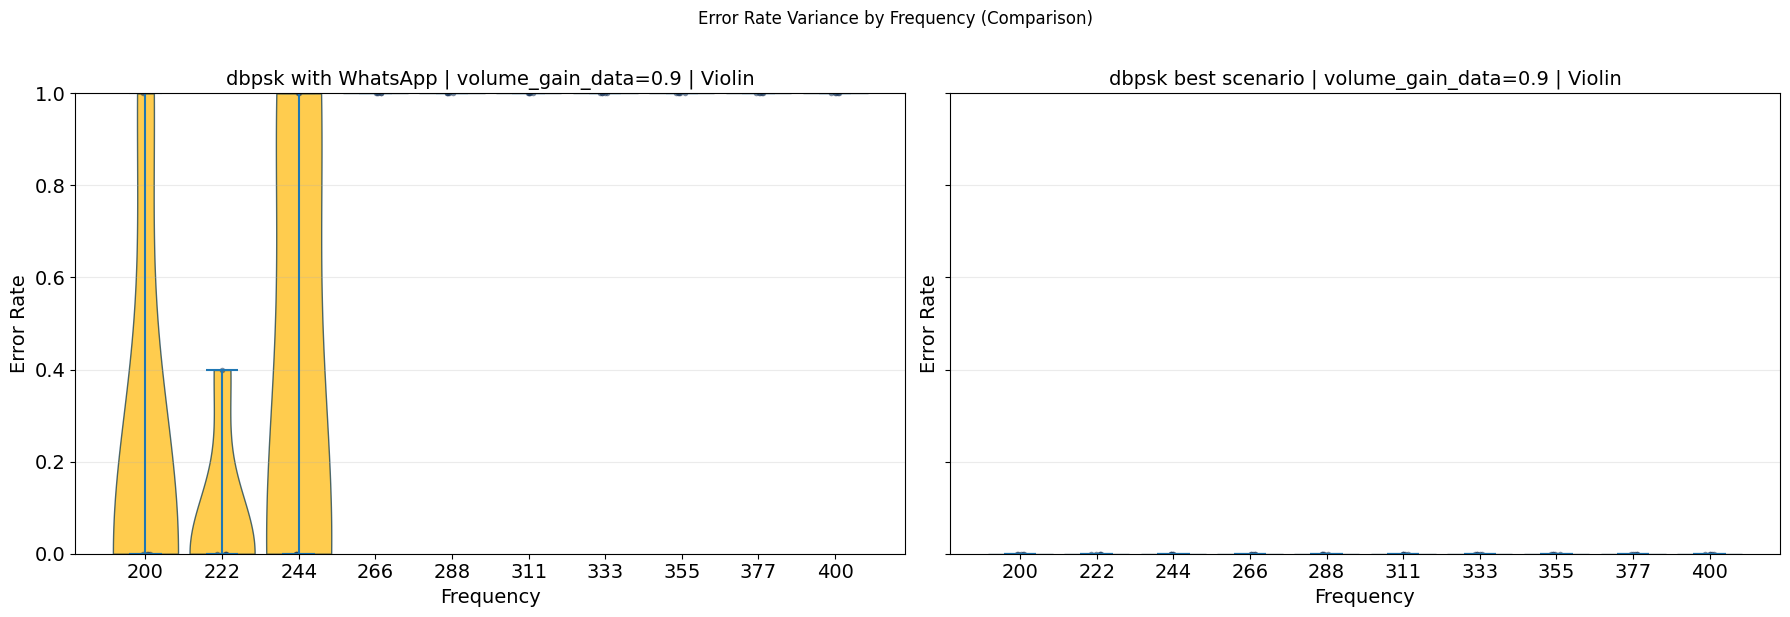

In [124]:
from plot_helpers import plot_error_rate_variance_for_all_volume_gains_comparison

figures = plot_error_rate_variance_for_all_volume_gains_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)
savefigs(figures, "violin")

## 3D Static Render (Non-interactive)
This adds a static 3D view of the same comparison data without changing the interactive Plotly figure above.

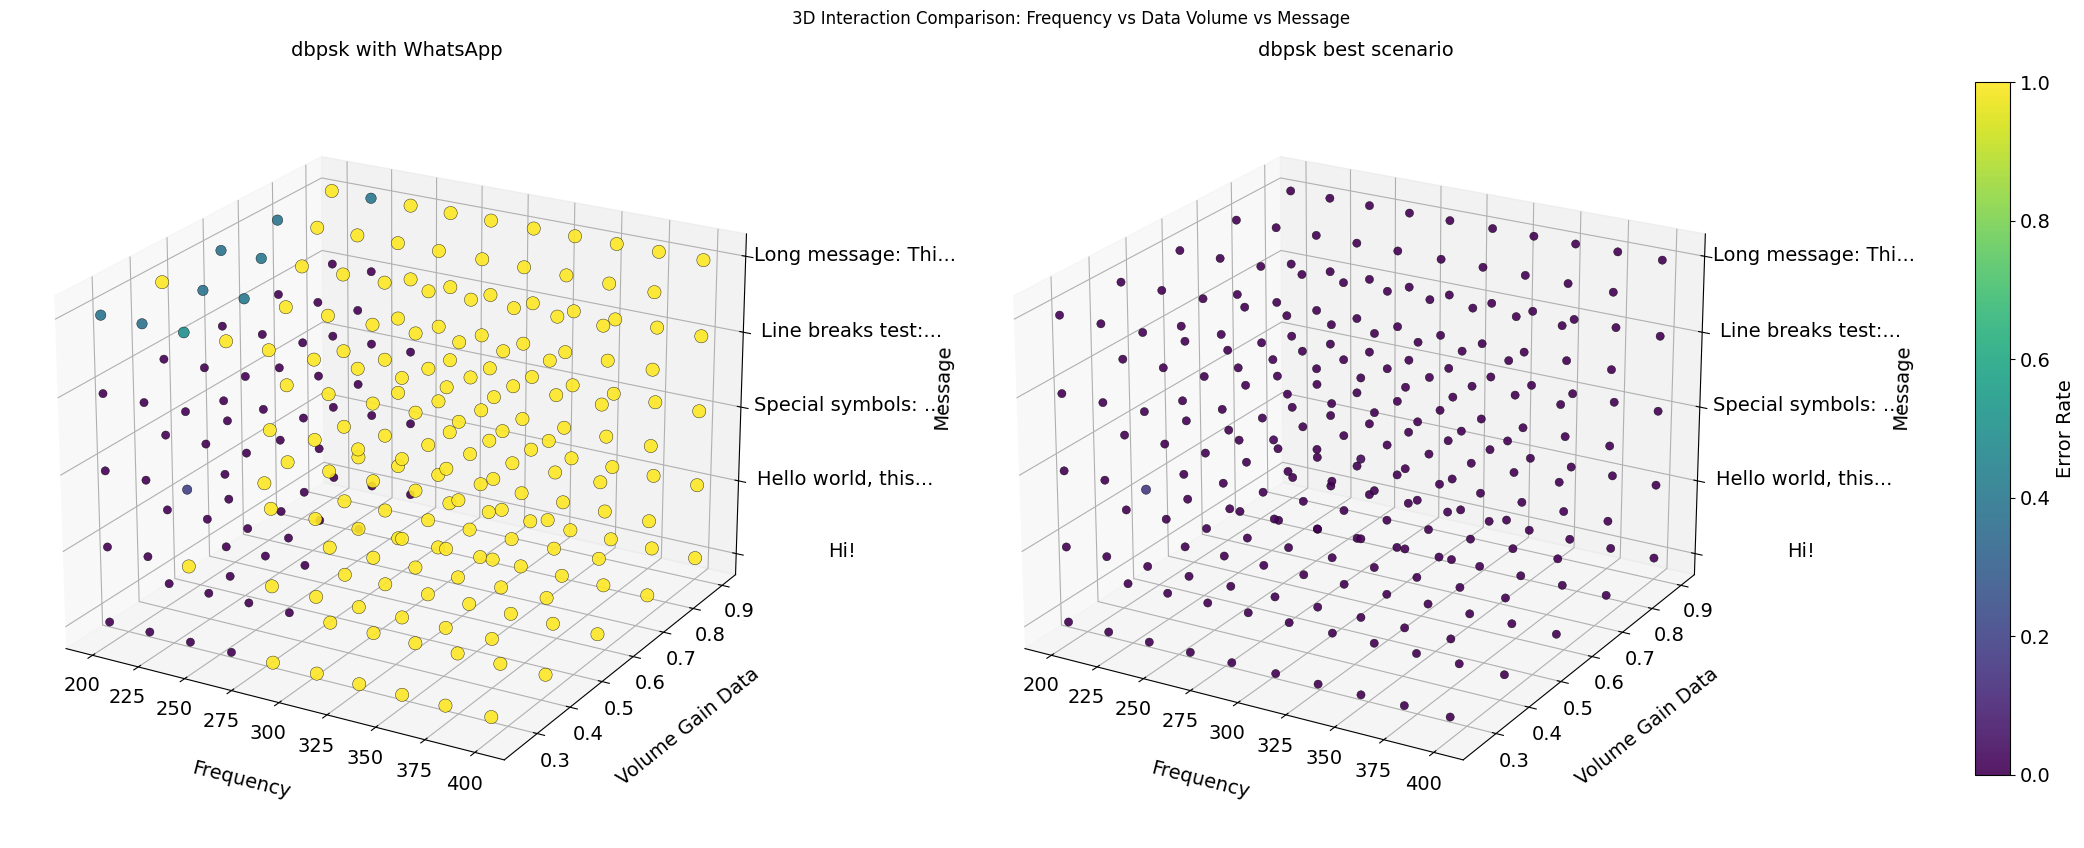

In [125]:
from plot_helpers import plot_static_3d_interaction_comparison

figure = plot_static_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)
savefigs([figure], "3D")

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [126]:
from plot_helpers import plot_3d_interaction_comparison

plot_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)